In [1]:
import model as m
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import numpy as np

### Parameter Values

- $\alpha$: infection rate from living hosts
- $\beta$: death rate from disease
- $\gamma$: infection rate from deceased hosts
- $\delta$: death rate of fungus in dead hosts
- $\zeta$: rate of transfer to heat treatment
- $\xi$: rate of transfer antifungal treatment
- $\eta$: rate at which individuals leave treatment

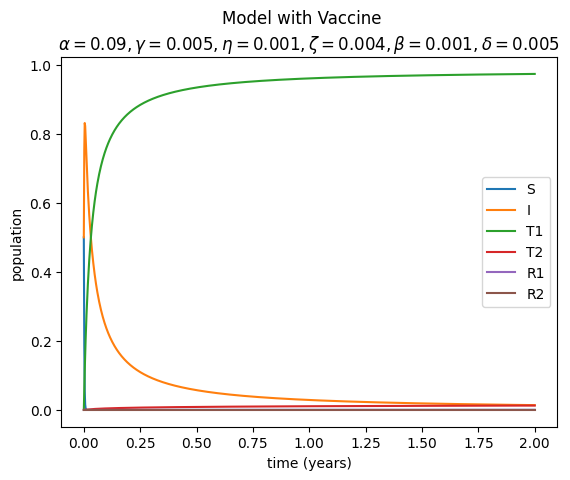

In [9]:
# define parameters for use with solve_ivp
initial = [4000, 4000, 0, 0, 0, 0]
alpha, gamma, eta, zeta, beta, delta, xi = .09, .005, .001, .004, .001, .005, .1
t0, tf = 0, 2
sol = solve_ivp(m.model_equation, t_span=[t0, tf], y0=initial, t_eval=np.linspace(t0, tf, 1000), args=[[alpha, gamma, eta, zeta, beta, delta, xi]])
t_vals = np.linspace(0, 2, 1000)

# graph each compartment
plt.plot(sol.t, sol.y[0] / sum(initial), label='S')
plt.plot(sol.t, sol.y[1] / sum(initial), label="I")
plt.plot(sol.t, sol.y[2] / sum(initial), label="T1")
plt.plot(sol.t, sol.y[3] / sum(initial), label="T2")
plt.plot(sol.t, sol.y[4] / sum(initial), label="R1")
plt.plot(sol.t, sol.y[5] / sum(initial), label="R2")

# label the graph
plt.suptitle(fr"Model with Vaccine")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \eta = {eta}, \zeta = {zeta}, \beta = {beta}, \delta = {delta}$")
plt.xlabel("time (years)")
plt.ylabel("population")
plt.legend()